Dataset: https://www.cs.toronto.edu/~kriz/cifar.html

Libraries required  

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models,optimizers, callbacks
from sklearn.metrics import confusion_matrix

In [ ]:
# Set up TensorFlow to use the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpus[0], True)

In [ ]:
train_data='/content/drive/MyDrive/colab projects/data_batch_1'
test_data='/content/drive/MyDrive/colab projects/test_batch'

In [ ]:
# unpickle the data
def unpickle(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict

# Read the training set
train_data_dict = unpickle(train_data)
data_train = train_data_dict[b'data']
label_train = np.array(train_data_dict[b'labels'])

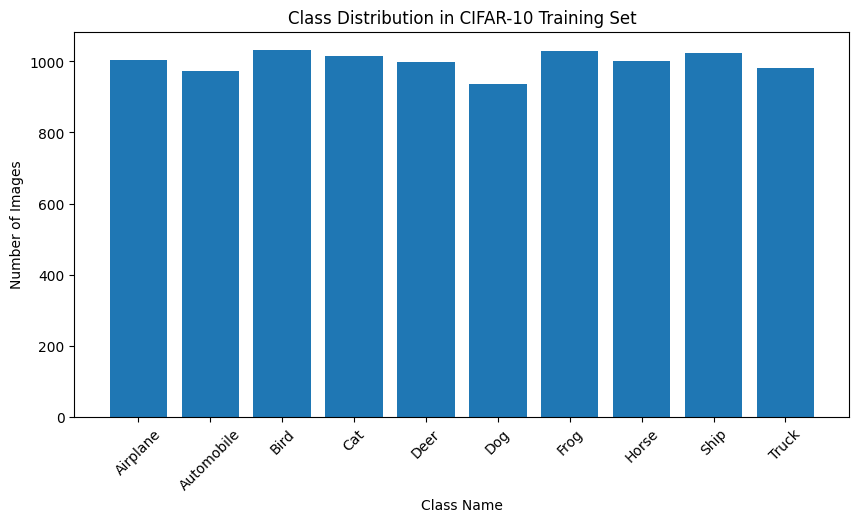

In [ ]:
# Function to convert the CIFAR-10 data format to an image
def cifar_image(data):
    img = data.reshape(3, 32, 32)
    img = np.transpose(img, (1, 2, 0))
    return img


# Plot a bar chart to visualize the class distribution
class_counts = np.bincount(label_train)
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

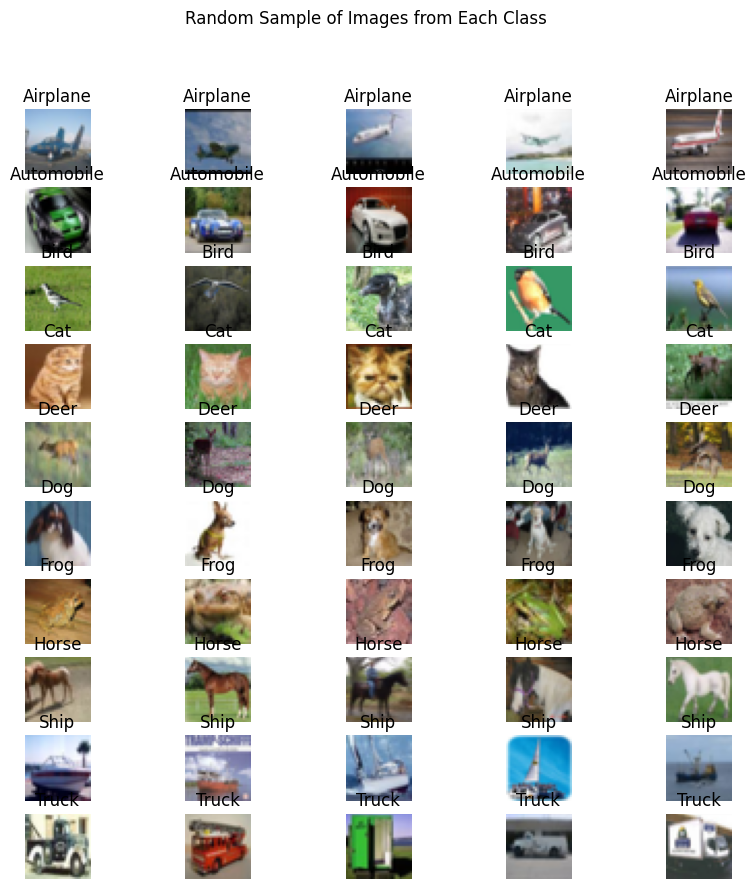

In [ ]:
# Display a random sample of images from each class
num_classes = len(class_names)
num_samples_per_class = 5  # Show 5 samples per class

plt.figure(figsize=(10, 10))
for i in range(num_classes):
    class_indices = np.where(label_train == i)[0]
    random_indices = np.random.choice(class_indices, num_samples_per_class, replace=False)

    for j, idx in enumerate(random_indices):
        plt.subplot(num_classes, num_samples_per_class, i * num_samples_per_class + j + 1)
        img = cifar_image(data_train[idx])
        plt.imshow(img)
        plt.title(class_names[i])
        plt.axis('off')

plt.suptitle("Random Sample of Images from Each Class")
plt.show()

Preprocess the data

In [ ]:
# Load and preprocess the CIFAR-10 data
def preprocess_cifar_data(data):
    # Normalize pixel values to the range [0, 1]
    data = data.astype('float32') / 255.0
    return data
data_train = preprocess_cifar_data(data_train)

Reshape the data to fit the input requirements of CNN

In [ ]:
data_train = data_train.reshape(-1, 32, 32, 3)

Train A CNN model

In [ ]:
# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # 10 classes in CIFAR-10
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 30, 30, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 15, 15, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 13, 13, 64)       2

In [ ]:
# Learning Rate Scheduler
def lr_scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [ ]:
epochs = 100
batch_size = 64
history = model.fit(data_train, label_train, epochs=epochs, batch_size=batch_size,
                    validation_split=0.1)

Epoch 1/100
141/141 [==============================] - 14s 14ms/step - loss: 2.6083 - accuracy: 0.2334 - val_loss: 3.0816 - val_accuracy: 0.1060
Epoch 2/100
141/141 [==============================] - 2s 12ms/step - loss: 2.0719 - accuracy: 0.3101 - val_loss: 3.2536 - val_accuracy: 0.1190
Epoch 3/100
141/141 [==============================] - 2s 14ms/step - loss: 1.8348 - accuracy: 0.3607 - val_loss: 2.3336 - val_accuracy: 0.2370
Epoch 4/100
141/141 [==============================] - 2s 14ms/step - loss: 1.7104 - accuracy: 0.3927 - val_loss: 1.6141 - val_accuracy: 0.4270
Epoch 5/100
141/141 [==============================] - 2s 15ms/step - loss: 1.6185 - accuracy: 0.4133 - val_loss: 1.6008 - val_accuracy: 0.4210
Epoch 6/100
141/141 [==============================] - 2s 16ms/step - loss: 1.5481 - accuracy: 0.4361 - val_loss: 1.6083 - val_accuracy: 0.4270
Epoch 7/100
141/141 [==============================] - 1s 9ms/step - loss: 1.4855 - accuracy: 0.4710 - val_loss: 1.4618 - val_accuracy:

In [ ]:
# Load and preprocess the CIFAR-10 data
def preprocess_cifar_data(data):
    # Normalize pixel values to the range [0, 1]
    data = data.astype('float32') / 255.0
    return data

test_data_path = '/content/drive/MyDrive/colab projects/test_batch'
test_data_dict = unpickle(test_data_path)
data_test = test_data_dict[b'data']
label_test = np.array(test_data_dict[b'labels'])

# Preprocess the test data
data_test = preprocess_cifar_data(data_test)

# Reshape the data to fit the input requirements of CNN
data_test = data_test.reshape(-1, 32, 32, 3)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(data_test, label_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 [==============================] - 1s 4ms/step - loss: 1.4957 - accuracy: 0.5967
Test Loss: 1.4957104921340942
Test Accuracy: 0.5967000126838684


313/313 [==============================] - 1s 4ms/step


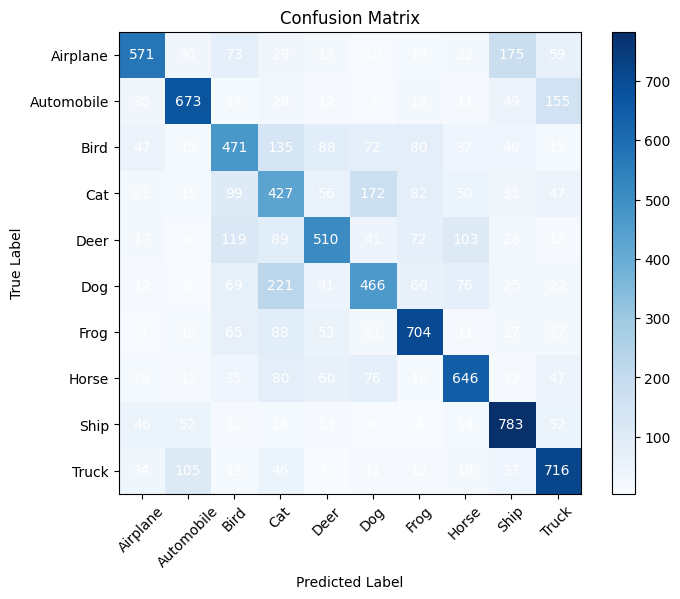

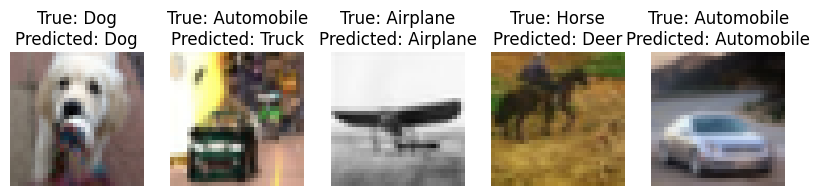

In [ ]:
# Make predictions on the test set
predictions = model.predict(data_test)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate the confusion matrix
cm = confusion_matrix(label_test, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add numerical values to the cells
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white')

plt.show()

# Visualize some individual test images with their predicted labels
num_samples_to_visualize = 5

plt.figure(figsize=(10, 10))
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    idx = np.random.randint(len(data_test))
    img = cifar_image(data_test[idx])
    true_label = class_names[label_test[idx]]
    predicted_label = class_names[predicted_labels[idx]]
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPredicted: {predicted_label}")
    plt.axis('off')

plt.show()